# 🧠 Phase 1 — Data Audit & Inventory
## Yale Brain Metastases Longitudinal Dataset

**Date**: March 10, 2026  
**Dataset**: Yale-Brain-Mets-Longitudinal  
**Goal**: Build a complete, reproducible inventory of every patient visit and file on disk.

---

### What This Notebook Does (End-to-End)

| Step | Output | Runtime |
|------|--------|---------|
| 1. GPU/Environment check | Hardware summary | ~5s |
| 2. Walk all 1,430 patient folders | Raw visit list | ~2 min |
| 3. Per-visit modality inventory | `data_inventory.csv` | included above |
| 4. NIfTI header integrity check | Shape + voxel flags | ~1–2 min |
| 5. Temporal features | `days_since_baseline`, `interval_days` | instant |
| 6. Usability classification | `FULL / PARTIAL_GOOD / UNUSABLE` | instant |
| 7. Clinical metadata parsing | `metadata.json` | ~30s |
| 8. Train/Val/Test split | `splits.json` | instant |
| 9. EDA — 6 publication-quality figures | PNG files | ~1 min |
| 10. Audit report | Printed + saved markdown | instant |

> **GPU note**: NIfTI header reads and folder walking are CPU-bound (I/O, not compute).  
> GPU is used for: batch array operations on the inventory DataFrame (via CuPy if available), and will be used in later phases for model inference.  
> If no GPU is available locally, all cells fall back to CPU automatically.

---

**Key numbers already known from prior analysis:**
- 📁 **1,430** patients
- 🗓️ **11,877** visit folders
- 🔬 **33,811** NIfTI files
- 💾 **~43 GB** on disk
- 🕐 Median follow-up: **345 days** | Max: **5,061 days** (13.9 years)
- ⚠️ Only **37.1%** of visits have all 4 modalities (PRE/POST/T2/FLAIR)

---
## Section 1 — Import Libraries

We import everything needed upfront so the kernel state is clean.  
- **Standard**: `os`, `re`, `json`, `pathlib`, `datetime`, `warnings`  
- **Data**: `pandas`, `numpy`  
- **Medical imaging**: `nibabel` (NIfTI header reads — very fast, no pixel data loaded)  
- **Visualization**: `matplotlib`, `seaborn`  
- **GPU (optional)**: `torch` to detect CUDA, `cupy` for GPU array ops if available

In [1]:
import os
import re
import json
import warnings
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm   # auto picks notebook widget if ipywidgets is installed, else plain text

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13})

print("✅ All standard libraries imported successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   nibabel : {nib.__version__}")

✅ All standard libraries imported successfully.
   pandas  : 3.0.1
   numpy   : 1.26.4
   nibabel : 5.3.3


---
## Section 2 — GPU Configuration & Device Setup

We detect CUDA availability and set up a `DEVICE` variable used throughout the notebook.  
Heavy compute (batch stats on large arrays) will use GPU tensors if available.  
All file I/O and NIfTI reading remain on CPU — that's an I/O bottleneck, not a compute bottleneck.

In [2]:
import torch

# ── GPU Detection ────────────────────────────────────────────────────────────
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")

print("=" * 55)
print("  🖥️  Hardware Summary")
print("=" * 55)
print(f"  PyTorch version  : {torch.__version__}")
print(f"  CUDA available   : {CUDA_AVAILABLE}")
print(f"  Active device    : {DEVICE}")

if CUDA_AVAILABLE:
    gpu_name   = torch.cuda.get_device_name(0)
    total_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU name         : {gpu_name}")
    print(f"  GPU memory       : {total_mem:.1f} GB")
    print(f"  CUDA version     : {torch.version.cuda}")
    print(f"  Device count     : {torch.cuda.device_count()}")
    GPU_MODE = True
else:
    print("  ⚠️  No GPU found — running on CPU.")
    print("     (This is fine for the audit step — it is I/O bound, not compute bound.)")
    print("     Heavy training will run on Kaggle T4 / Colab.")
    GPU_MODE = False

# ── Optional: CuPy for GPU array ops ────────────────────────────────────────
try:
    import cupy as cp
    CUPY_AVAILABLE = True
    print(f"\n  CuPy available   : {cp.__version__} — GPU array ops enabled ✅")
except ImportError:
    CUPY_AVAILABLE = False
    print("\n  CuPy             : not installed — using NumPy (CPU) for array ops.")

print("=" * 55)

  🖥️  Hardware Summary
  PyTorch version  : 2.10.0+cu128
  CUDA available   : False
  Active device    : cpu
  ⚠️  No GPU found — running on CPU.
     (This is fine for the audit step — it is I/O bound, not compute bound.)
     Heavy training will run on Kaggle T4 / Colab.

  CuPy             : not installed — using NumPy (CPU) for array ops.


---
## Section 3 — Path Configuration

All paths are defined in one place. If you move the data or clone this repo on another machine, **only change this cell**.

In [3]:
# ── Root paths ───────────────────────────────────────────────────────────────
WORKSPACE     = Path("/home/moamed/canada_me/explainable_diseas")
DATA_ROOT     = WORKSPACE / "implementation/Data/Yale-Brain-Mets-Longitudinal"
CLINICAL_XLSX = WORKSPACE / "implementation/Data/Yale-Brain-Mets-Longitudinal_ClinicalData_20250605.xlsx"
OUTPUTS_DIR   = WORKSPACE / "implementation/outputs"
EDA_DIR       = OUTPUTS_DIR / "eda/figures"

# ── Create output directories ─────────────────────────────────────────────────
for d in [OUTPUTS_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Modality tags in the file naming convention ───────────────────────────────
# File pattern: YG_<PATIENT_ID>_<YYYY-MM-DD>_<HH-MM-SS>_<MODALITY>.nii.gz
# PRE  = T1 pre-contrast
# POST = T1 post-contrast (T1c) — the most important modality
# T2   = T2-weighted
# FLAIR = T2-FLAIR (fluid-attenuated inversion recovery)
MODALITIES = ["PRE", "POST", "T2", "FLAIR"]

# ── Verify data root exists ───────────────────────────────────────────────────
assert DATA_ROOT.exists(), f"❌ Data root not found: {DATA_ROOT}"
assert CLINICAL_XLSX.exists(), f"❌ Clinical Excel not found: {CLINICAL_XLSX}"

patient_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith("YG_")])
print(f"✅ Data root     : {DATA_ROOT}")
print(f"✅ Clinical XLSX : {CLINICAL_XLSX}")
print(f"✅ Outputs dir   : {OUTPUTS_DIR}")
print(f"📁 Patient dirs found : {len(patient_dirs)}")

✅ Data root     : /home/moamed/canada_me/explainable_diseas/implementation/Data/Yale-Brain-Mets-Longitudinal
✅ Clinical XLSX : /home/moamed/canada_me/explainable_diseas/implementation/Data/Yale-Brain-Mets-Longitudinal_ClinicalData_20250605.xlsx
✅ Outputs dir   : /home/moamed/canada_me/explainable_diseas/implementation/outputs
📁 Patient dirs found : 1430


---
## Section 4 — Walk All Patient Folders → Raw Visit List

We traverse the full directory tree:  
`DATA_ROOT / YG_<PATIENT_ID> / YYYY-MM-DD / *.nii.gz`

For each visit folder we record:
- Which of the 4 modalities (PRE / POST / T2 / FLAIR) are present
- The full path to each NIfTI file

This is **pure I/O** — no file contents are loaded, just directory listing. Expected time: ~30–60 seconds for 11,877 folders.

In [4]:
records = []  # one dict per visit

for patient_dir in tqdm(patient_dirs, desc="Scanning patients", unit="patient"):
    patient_id = patient_dir.name

    # Collect visit date folders (YYYY-MM-DD format)
    visit_dirs = sorted([
        v for v in patient_dir.iterdir()
        if v.is_dir() and re.match(r"\d{4}-\d{2}-\d{2}", v.name)
    ])

    for visit_dir in visit_dirs:
        visit_date_str = visit_dir.name

        # Detect which modalities are present in this visit folder
        nii_files = list(visit_dir.glob("*.nii.gz"))
        modality_present = {m: False for m in MODALITIES}
        modality_paths   = {m: None  for m in MODALITIES}

        for nii_file in nii_files:
            fname = nii_file.name.upper()
            for mod in MODALITIES:
                if fname.endswith(f"_{mod}.NII.GZ"):
                    modality_present[mod] = True
                    modality_paths[mod]   = str(nii_file)

        records.append({
            "patient_id"   : patient_id,
            "visit_date"   : visit_date_str,
            "visit_dir"    : str(visit_dir),
            "has_PRE"      : modality_present["PRE"],
            "has_POST"     : modality_present["POST"],
            "has_T2"       : modality_present["T2"],
            "has_FLAIR"    : modality_present["FLAIR"],
            "n_modalities" : sum(modality_present.values()),
            "n_nii_files"  : len(nii_files),
            "path_PRE"     : modality_paths["PRE"],
            "path_POST"    : modality_paths["POST"],
            "path_T2"      : modality_paths["T2"],
            "path_FLAIR"   : modality_paths["FLAIR"],
        })

df_raw = pd.DataFrame(records)
df_raw["visit_date"] = pd.to_datetime(df_raw["visit_date"])

print(f"✅ Folder walk complete.")
print(f"   Total patients : {df_raw['patient_id'].nunique():,}")
print(f"   Total visits   : {len(df_raw):,}")
print(f"   Total NII files: {df_raw['n_nii_files'].sum():,}")
df_raw.head(8)

Scanning patients:   0%|          | 0/1430 [00:00<?, ?patient/s]

✅ Folder walk complete.
   Total patients : 1,430
   Total visits   : 11,877
   Total NII files: 33,811


,patient_id,visit_date,visit_dir,has_PRE,has_POST,has_T2,has_FLAIR,n_modalities,n_nii_files,path_PRE,path_POST,path_T2,path_FLAIR
0,YG_01M98EKKAR50,2016-11-13,/home/moamed/canada_me/explainable_diseas/impl...,True,True,True,True,4,4,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...
1,YG_01M98EKKAR50,2016-11-27,/home/moamed/canada_me/explainable_diseas/impl...,False,True,False,False,1,1,NaN,/home/moamed/canada_me/explainable_diseas/impl...,NaN,NaN
2,YG_01M98EKKAR50,2016-12-20,/home/moamed/canada_me/explainable_diseas/impl...,False,False,False,True,1,1,NaN,NaN,NaN,/home/moamed/canada_me/explainable_diseas/impl...
3,YG_021XTGZ9QY91,2016-01-30,/home/moamed/canada_me/explainable_diseas/impl...,True,True,True,True,4,4,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...
4,YG_021XTGZ9QY91,2016-02-08,/home/moamed/canada_me/explainable_diseas/impl...,False,True,False,False,1,1,NaN,/home/moamed/canada_me/explainable_diseas/impl...,NaN,NaN
5,YG_021XTGZ9QY91,2016-03-21,/home/moamed/canada_me/explainable_diseas/impl...,True,True,True,True,4,4,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...
6,YG_021XTGZ9QY91,2016-05-18,/home/moamed/canada_me/explainable_diseas/impl...,True,False,True,True,3,3,/home/moamed/canada_me/explainable_diseas/impl...,NaN,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...
7,YG_021XTGZ9QY91,2016-07-20,/home/moamed/canada_me/explainable_diseas/impl...,False,True,False,True,2,2,NaN,/home/moamed/canada_me/explainable_diseas/impl...,NaN,/home/moamed/canada_me/explainable_diseas/impl...


---
## Section 5 — NIfTI Header Integrity Check

For every NIfTI file we **load the header only** (no pixel data — this is very fast, ~1ms per file).  
We check:
1. File can be opened at all (no corruption)
2. Image is 3D (not accidentally 4D)
3. Voxel spacing (`zooms`) is valid: all > 0 mm and all < 15 mm
4. Image shape is reasonable for a brain MRI

> **Why header-only?** Loading the full voxel array for 33,811 × ~60MB files would require ~2 TB of RAM. Header-only reads are ~1ms each vs. ~1s for full loads. Total estimated time: ~1–3 minutes.

Files that fail are flagged as `CORRUPT` and excluded from all downstream processing.

In [5]:
def check_nifti_header(filepath: str) -> dict:
    """
    Load NIfTI header only (no voxel data) and validate it.
    Returns a dict with shape, voxel_size, and ok/error flags.
    """
    result = {
        "shape_ok"      : False,
        "voxel_ok"      : False,
        "is_3d"         : False,
        "shape"         : None,
        "voxel_size_mm" : None,
        "error"         : None,
    }
    try:
        img    = nib.load(filepath)          # header only (nibabel lazy-loads)
        shape  = img.shape
        zooms  = img.header.get_zooms()[:3]  # (dx, dy, dz) in mm

        result["shape"]         = list(shape)
        result["voxel_size_mm"] = [round(float(z), 3) for z in zooms]
        result["is_3d"]         = (len(shape) == 3)
        result["shape_ok"]      = result["is_3d"] and all(s > 0 for s in shape)
        result["voxel_ok"]      = all(0 < z < 15 for z in zooms)

    except Exception as e:
        result["error"] = str(e)

    return result


# ── Collect only paths that actually exist (non-null) ─────────────────────────
integrity_records = []
all_nii_paths = []

for _, row in df_raw.iterrows():
    for mod in MODALITIES:
        p = row[f"path_{mod}"]
        # pandas NaN is a float — check with pd.notna()
        if pd.notna(p) and isinstance(p, str) and p != "":
            all_nii_paths.append((row["patient_id"], row["visit_date"].strftime("%Y-%m-%d"), mod, p))

print(f"📂 Total NIfTI files to check: {len(all_nii_paths):,}  (only files that are present)")
print("   Running header checks (header-only, no pixel data loaded)...")

for patient_id, visit_date, modality, fpath in tqdm(all_nii_paths, desc="Checking headers", unit="file"):
    chk = check_nifti_header(fpath)
    integrity_records.append({
        "patient_id"    : patient_id,
        "visit_date"    : visit_date,
        "modality"      : modality,
        "filepath"      : fpath,
        "shape"         : str(chk["shape"]),
        "voxel_size_mm" : str(chk["voxel_size_mm"]),
        "is_3d"         : chk["is_3d"],
        "shape_ok"      : chk["shape_ok"],
        "voxel_ok"      : chk["voxel_ok"],
        "error"         : chk["error"],
        "header_ok"     : chk["shape_ok"] and chk["voxel_ok"],
    })

df_integrity = pd.DataFrame(integrity_records)

n_total   = len(df_integrity)
n_ok      = df_integrity["header_ok"].sum()
n_corrupt = (~df_integrity["header_ok"]).sum()
n_errors  = df_integrity["error"].notna().sum()

print(f"\n✅ Header check complete.")
print(f"   Total files checked : {n_total:,}")
print(f"   ✅ OK               : {n_ok:,}  ({100*n_ok/n_total:.1f}%)")
print(f"   ⚠️  Issues           : {n_corrupt:,}  ({100*n_corrupt/n_total:.1f}%)")
print(f"   ❌ Read errors      : {n_errors:,}")

if n_errors > 0:
    print("\n   Corrupt/unreadable files:")
    print(df_integrity[df_integrity["error"].notna()][["patient_id","visit_date","modality","error"]])

📂 Total NIfTI files to check: 33,804  (only files that are present)
   Running header checks (header-only, no pixel data loaded)...


Checking headers:   0%|          | 0/33804 [00:00<?, ?file/s]


✅ Header check complete.
   Total files checked : 33,804
   ✅ OK               : 33,804  (100.0%)
   ⚠️  Issues           : 0  (0.0%)
   ❌ Read errors      : 0


---
## Section 6 — Temporal Features & Usability Classification

Now we enrich the inventory with:

**Temporal features:**
- `visit_idx` — 0-based index of this visit within the patient's sorted sequence
- `days_since_baseline` — days elapsed since the patient's **first** visit (baseline = 0)
- `interval_days` — days since the **previous** visit (NaN for first visit)
- `same_day_flag` — True if interval < 2 days (possible repeat scan / duplicate)

**Usability classification:**

| Class | Criteria | Use in Training |
|-------|----------|----------------|
| `FULL` | All 4 modalities present + all headers OK | ✅ Best — use for everything |
| `PARTIAL_GOOD` | POST + FLAIR present (minimum viable) + headers OK | ✅ Use with modality dropout |
| `UNUSABLE` | Missing POST or FLAIR, or corrupt file | ❌ Exclude from training |

In [6]:
# ── Build per-visit integrity flags by joining with df_integrity ──────────────
integrity_by_visit = (
    df_integrity
    .groupby(["patient_id", "visit_date"])["header_ok"]
    .all()
    .reset_index()
    .rename(columns={"header_ok": "all_headers_ok"})
)
integrity_by_visit["visit_date"] = pd.to_datetime(integrity_by_visit["visit_date"])

df = df_raw.merge(integrity_by_visit, on=["patient_id", "visit_date"], how="left")
df["all_headers_ok"] = df["all_headers_ok"].fillna(False)

# ── Sort by patient + date (critical for temporal indexing) ───────────────────
df = df.sort_values(["patient_id", "visit_date"]).reset_index(drop=True)

# ── Temporal features ─────────────────────────────────────────────────────────
baseline_dates = df.groupby("patient_id")["visit_date"].transform("min")
df["days_since_baseline"] = (df["visit_date"] - baseline_dates).dt.days

df["visit_idx"] = df.groupby("patient_id").cumcount()

df["interval_days"] = (
    df.groupby("patient_id")["visit_date"]
    .diff()
    .dt.days
)
df["same_day_flag"] = df["interval_days"].fillna(999) < 2

# ── Training Usability Label ──────────────────────────────────────────────────
# This label describes HOW a visit can be used in training — NOT whether the
# data is valid. All visits are real MRI data. The hierarchy is:
#
#   FULL          → All 4 modalities → use for full supervised training
#   PARTIAL_GOOD  → POST + FLAIR (+ optionally PRE or T2) → supervised w/ modality dropout
#   POST_ONLY     → POST present but no FLAIR → self-supervised pretraining only
#   UNUSABLE      → No POST (cannot see tumor enhancement at all)
#   CORRUPT       → Header read failed

def classify_training_usability(row):
    if not row["all_headers_ok"]:
        return "CORRUPT"
    if row["has_PRE"] and row["has_POST"] and row["has_T2"] and row["has_FLAIR"]:
        return "FULL"
    if row["has_POST"] and row["has_FLAIR"]:
        return "PARTIAL_GOOD"      # POST+FLAIR ± PRE ± T2
    if row["has_POST"]:
        return "POST_ONLY"         # Can see tumor; no FLAIR → pretrain only
    return "UNUSABLE"              # No POST = cannot see enhancement

df["training_usability"] = df.apply(classify_training_usability, axis=1)

# ── Summary ───────────────────────────────────────────────────────────────────
ORDER   = ["FULL", "PARTIAL_GOOD", "POST_ONLY", "UNUSABLE", "CORRUPT"]
total   = len(df)
print("=" * 65)
print("  📊  Visit Training Usability Labels")
print("=" * 65)
print(f"  {'Label':<18} {'Count':>7}  {'%':>6}  {'Use in training'}")
print(f"  {'-'*60}")
descriptions = {
    "FULL"         : "Full supervised training",
    "PARTIAL_GOOD" : "Supervised w/ modality dropout",
    "POST_ONLY"    : "Self-supervised pretraining only",
    "UNUSABLE"     : "Temporal context only (no tumor signal)",
    "CORRUPT"      : "Excluded entirely",
}
for lbl in ORDER:
    cnt = (df["training_usability"] == lbl).sum()
    print(f"  {lbl:<18} {cnt:>7,}  {100*cnt/total:>5.1f}%  {descriptions[lbl]}")
print(f"  {'TOTAL':<18} {total:>7,}")
print("=" * 65)

# ── Longitudinal eligibility (using FULL + PARTIAL_GOOD as "supervised usable") ─
supervised_usable = df[df["training_usability"].isin(["FULL", "PARTIAL_GOOD"])]
sup_per_patient   = supervised_usable.groupby("patient_id").size()
print(f"\n  Supervised-usable longitudinal patients:")
print(f"  ≥2 supervised visits : {(sup_per_patient >= 2).sum():,}")
print(f"  ≥3 supervised visits : {(sup_per_patient >= 3).sum():,}")
print(f"  ≥5 supervised visits : {(sup_per_patient >= 5).sum():,}")

# Also keep old "usability" column name as alias for backward compat
df["usability"] = df["training_usability"]

df.head(6)

  📊  Visit Training Usability Labels
  Label                Count       %  Use in training
  ------------------------------------------------------------
  FULL                 4,364   36.7%  Full supervised training
  PARTIAL_GOOD         2,278   19.2%  Supervised w/ modality dropout
  POST_ONLY            2,352   19.8%  Self-supervised pretraining only
  UNUSABLE             2,883   24.3%  Temporal context only (no tumor signal)
  CORRUPT                  0    0.0%  Excluded entirely
  TOTAL               11,877

  Supervised-usable longitudinal patients:
  ≥2 supervised visits : 931
  ≥3 supervised visits : 724
  ≥5 supervised visits : 480


,patient_id,visit_date,visit_dir,has_PRE,has_POST,has_T2,has_FLAIR,n_modalities,n_nii_files,path_PRE,path_POST,path_T2,path_FLAIR,all_headers_ok,days_since_baseline,visit_idx,interval_days,same_day_flag,training_usability,usability
0,YG_01M98EKKAR50,2016-11-13,/home/moamed/canada_me/explainable_diseas/impl...,True,True,True,True,4,4,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,True,0,0,NaN,False,FULL,FULL
1,YG_01M98EKKAR50,2016-11-27,/home/moamed/canada_me/explainable_diseas/impl...,False,True,False,False,1,1,NaN,/home/moamed/canada_me/explainable_diseas/impl...,NaN,NaN,True,14,1,14.00,False,POST_ONLY,POST_ONLY
2,YG_01M98EKKAR50,2016-12-20,/home/moamed/canada_me/explainable_diseas/impl...,False,False,False,True,1,1,NaN,NaN,NaN,/home/moamed/canada_me/explainable_diseas/impl...,True,37,2,23.00,False,UNUSABLE,UNUSABLE
3,YG_021XTGZ9QY91,2016-01-30,/home/moamed/canada_me/explainable_diseas/impl...,True,True,True,True,4,4,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,True,0,0,NaN,False,FULL,FULL
4,YG_021XTGZ9QY91,2016-02-08,/home/moamed/canada_me/explainable_diseas/impl...,False,True,False,False,1,1,NaN,/home/moamed/canada_me/explainable_diseas/impl...,NaN,NaN,True,9,1,9.00,False,POST_ONLY,POST_ONLY
5,YG_021XTGZ9QY91,2016-03-21,/home/moamed/canada_me/explainable_diseas/impl...,True,True,True,True,4,4,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,/home/moamed/canada_me/explainable_diseas/impl...,True,51,2,42.00,False,FULL,FULL


---
## Section 7 — Save `data_inventory.csv`

This is the **master ledger** of the entire dataset. Every downstream script reads this file — it is the ground truth of what exists on disk.

Columns saved:
- `patient_id`, `visit_date`, `visit_idx`, `days_since_baseline`, `interval_days`
- `has_PRE`, `has_POST`, `has_T2`, `has_FLAIR`, `n_modalities`
- `usability`, `all_headers_ok`, `same_day_flag`
- `path_PRE`, `path_POST`, `path_T2`, `path_FLAIR` (absolute paths to each file)

In [7]:
INVENTORY_CSV = OUTPUTS_DIR / "data_inventory.csv"

cols_to_save = [
    "patient_id", "visit_date", "visit_dir",
    "visit_idx", "days_since_baseline", "interval_days", "same_day_flag",
    "has_PRE", "has_POST", "has_T2", "has_FLAIR", "n_modalities",
    "training_usability", "all_headers_ok", "n_nii_files",
    "path_PRE", "path_POST", "path_T2", "path_FLAIR",
]
df[cols_to_save].to_csv(INVENTORY_CSV, index=False)

print(f"✅ Saved: {INVENTORY_CSV}")
print(f"   Shape  : {df.shape[0]:,} rows × {len(cols_to_save)} columns")
print(f"   Size   : {INVENTORY_CSV.stat().st_size / 1e6:.1f} MB")
print(f"\n   Column list:")
for i, c in enumerate(cols_to_save, 1):
    print(f"   {i:>2}. {c}")

✅ Saved: /home/moamed/canada_me/explainable_diseas/implementation/outputs/data_inventory.csv
   Shape  : 11,877 rows × 19 columns
   Size   : 8.0 MB

   Column list:
    1. patient_id
    2. visit_date
    3. visit_dir
    4. visit_idx
    5. days_since_baseline
    6. interval_days
    7. same_day_flag
    8. has_PRE
    9. has_POST
   10. has_T2
   11. has_FLAIR
   12. n_modalities
   13. training_usability
   14. all_headers_ok
   15. n_nii_files
   16. path_PRE
   17. path_POST
   18. path_T2
   19. path_FLAIR


---
## Section 8 — Clinical Metadata Parsing

The Excel file `Yale-Brain-Mets-Longitudinal_ClinicalData_20250605.xlsx` contains clinical information about each patient.  

We:
1. Print all column names (we don't know them in advance)
2. Identify patient ID column and key clinical variables
3. Build `metadata.json` keyed by `patient_id`

This metadata will be used in:
- **Phase 3**: ComBat harmonization needs scanner manufacturer / field strength
- **Phase 4**: LLM prompts need age, sex, treatment type, diagnosis info

In [8]:
# ── Load all sheets in the Excel ─────────────────────────────────────────────
xl_sheets = pd.read_excel(CLINICAL_XLSX, sheet_name=None)

print(f"📋 Excel file: {CLINICAL_XLSX.name}")
print(f"   Sheets found ({len(xl_sheets)}): {list(xl_sheets.keys())}\n")

for sheet_name, sheet_df in xl_sheets.items():
    print(f"── Sheet: '{sheet_name}' — shape: {sheet_df.shape} ──")
    print(f"   Columns: {list(sheet_df.columns)}")
    print(sheet_df.head(3).to_string())
    print()

📋 Excel file: Yale-Brain-Mets-Longitudinal_ClinicalData_20250605.xlsx
   Sheets found (4): ['Data Dictionary', 'Clinical_data', 'Acquisition_data', 'image_acquisition_parameters']

── Sheet: 'Data Dictionary' — shape: (4, 2) ──
   Columns: ['Data Collection Name', 'Data Descriptor /Metadata Name']
  Data Collection Name  Data Descriptor /Metadata Name
0           Patient ID   Patient Identification Number
1       Study-Datetime  Anonymized Study Date and Time
2         Age at Study                  Age at Imaging

── Sheet: 'Clinical_data' — shape: (11884, 4) ──
   Columns: ['patient_id', 'study_datetime', 'age_at_Imaging (years)', 'sex']
        patient_id       study_datetime  age_at_Imaging (years)     sex
0  YG_01M98EKKAR50  2016-11-13_10-16-23                      71  Female
1  YG_01M98EKKAR50  2016-11-27_10-38-46                      71  Female
2  YG_01M98EKKAR50  2016-12-20_12-21-10                      71  Female

── Sheet: 'Acquisition_data' — shape: (11884, 11) ──
   Columns:

In [9]:
# ── Auto-detect patient ID column and build metadata dict ────────────────────
# Use the first sheet (most datasets have one main sheet)
df_clinical = list(xl_sheets.values())[0].copy()

# Normalize column names: lowercase + strip whitespace
df_clinical.columns = [str(c).strip().lower().replace(" ", "_") for c in df_clinical.columns]

print("Normalized column names:")
for i, c in enumerate(df_clinical.columns, 1):
    print(f"  {i:>2}. {c}  (dtype: {df_clinical[c].dtype}, non-null: {df_clinical[c].notna().sum()})")

# Try to detect patient ID column automatically
id_candidates = [c for c in df_clinical.columns if "id" in c or "patient" in c or "subject" in c]
print(f"\n  Patient ID column candidates: {id_candidates}")
print(f"\n  Shape: {df_clinical.shape}")

Normalized column names:
   1. data_collection_name  (dtype: str, non-null: 4)
   2. data_descriptor_/metadata_name  (dtype: str, non-null: 4)

  Patient ID column candidates: []

  Shape: (4, 2)


In [10]:
# ── Use the correct sheets directly ──────────────────────────────────────────
df_clinical     = xl_sheets["Clinical_data"].copy()
df_acquisition  = xl_sheets["Acquisition_data"].copy()
df_seq_params   = xl_sheets["image_acquisition_parameters"].copy()

# Normalize column names
for _df in [df_clinical, df_acquisition, df_seq_params]:
    _df.columns = [str(c).strip().lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/","_") for c in _df.columns]

print("Clinical_data columns    :", list(df_clinical.columns))
print("Acquisition_data columns :", list(df_acquisition.columns))
print()

# ── Merge clinical + acquisition on patient_id + study_datetime ──────────────
df_merged = df_clinical.merge(df_acquisition, on=["patient_id", "study_datetime"], how="left")

# ── Extract visit_date from study_datetime (format: YYYY-MM-DD_HH-MM-SS) ─────
df_merged["visit_date"] = df_merged["study_datetime"].str[:10]

# ── Build metadata.json: one entry per patient (take first row for static info) ─
metadata = {}
for pid, grp in df_merged.groupby("patient_id"):
    first = grp.iloc[0]
    # Static patient-level info
    entry = {
        "age_at_first_imaging" : int(first["age_at_imaging_years"]) if pd.notna(first["age_at_imaging_years"]) else None,
        "sex"                  : str(first["sex"]) if pd.notna(first["sex"]) else None,
        "scanner_vendor"       : str(first["vendor"]) if "vendor" in grp.columns and pd.notna(first["vendor"]) else None,
        "scanner_site"         : str(first["scanner_site"]) if "scanner_site" in grp.columns and pd.notna(first["scanner_site"]) else None,
        # Per-visit acquisition details
        "visits": []
    }
    for _, row in grp.sort_values("visit_date").iterrows():
        visit_entry = {
            "visit_date"   : row["visit_date"],
            "study_datetime": row["study_datetime"],
        }
        for col in ["vendor", "model", "field_strength_t", "2d_3d_acquisition", "scanner_site",
                    "pre_included_1=present;_0=absent", "post_included_1=present;_0=absent",
                    "t2_included_1=present;_0=absent", "flair_included_1=present;_0=absent"]:
            if col in row.index and pd.notna(row[col]):
                clean_key = col.replace("_1=present;_0=absent","").replace("_t","_tesla")
                val = row[col]
                visit_entry[clean_key] = val.item() if hasattr(val, "item") else val
        entry["visits"].append(visit_entry)
    metadata[pid] = entry

# Save metadata.json
METADATA_JSON = OUTPUTS_DIR / "metadata.json"
with open(METADATA_JSON, "w") as f:
    json.dump(metadata, f, indent=2, default=str)

# Coverage check
inventory_patients = set(df["patient_id"].unique())
metadata_patients  = set(metadata.keys())
covered = inventory_patients & metadata_patients
print(f"✅ Saved: {METADATA_JSON}")
print(f"   Patients in clinical data   : {len(metadata_patients):,}")
print(f"   Patients in data inventory  : {len(inventory_patients):,}")
print(f"   ✅ Covered in both          : {len(covered):,}")
print(f"   ⚠️  Not in Excel            : {len(inventory_patients - metadata_patients):,}")
print(f"\n   Sample entry for '{sorted(covered)[0]}':")
sample = metadata[sorted(covered)[0]].copy()
sample["visits"] = sample["visits"][:2]  # show only first 2 visits
print(json.dumps(sample, indent=4, default=str))

Clinical_data columns    : ['patient_id', 'study_datetime', 'age_at_imaging_years', 'sex']
Acquisition_data columns : ['patient_id', 'study_datetime', 'vendor', 'model', 'field_strength_t', '2d_3d_acquisition', 'scanner_site', 'pre_included_1=present;_0=absent', 'post_included_1=present;_0=absent', 't2_included_1=present;_0=absent', 'flair_included_1=present;_0=absent']

✅ Saved: /home/moamed/canada_me/explainable_diseas/implementation/outputs/metadata.json
   Patients in clinical data   : 1,430
   Patients in data inventory  : 1,430
   ✅ Covered in both          : 1,430
   ⚠️  Not in Excel            : 0

   Sample entry for 'YG_01M98EKKAR50':
{
    "age_at_first_imaging": 71,
    "sex": "Female",
    "scanner_vendor": "SIEMENS",
    "scanner_site": "Yale",
    "visits": [
        {
            "visit_date": "2016-11-13",
            "study_datetime": "2016-11-13_10-16-23",
            "vendor": "SIEMENS",
            "model": "Verio",
            "field_strength_tesla": 3.0,
        

---
## Section 9 — Patient-Level Timeline Summary

We compute per-patient summary statistics and build `patient_timelines.json` — a dictionary mapping each patient ID to their sorted list of visits with temporal metadata.

This file is used by:
- **Phase 3 (TaViT)**: needs exact `days_since_baseline` for time-distance positional encoding
- **Phase 5 (split)**: stratification by visit count bucket

---
## Section 8b — Image Acquisition Parameters (4th Sheet)

The sheet `image_acquisition_parameters` has **one row per NIfTI file** (33,812 rows) and contains the actual MRI sequence parameters extracted from DICOM headers:

| Column | Meaning |
|--------|---------|
| `file_name` | `YG_<ID>_<DATE>_<MOD>.nii.gz` — links to our inventory |
| `sequence_class` | PRE / POST / T2 / FLAIR |
| `sequence_tags` | Human-readable protocol name (e.g. `ax_t1_se_gd`) |
| `slice_thickness (mm)` | Slice thickness |
| `spacing_between_slices (mm)` | Gap between slices |
| `repetition_time (ms)` | TR |
| `echo_time (ms)` | TE |
| `inversion_time (ms)` | TI (used in FLAIR / MP-RAGE) |

**Why this matters:**
- TR/TE/TI vary across scanners — needed for **ComBat harmonization** (Phase 3)
- Slice thickness affects spatial resolution — impacts preprocessing choices
- Sequence tags reveal protocol variability across sites/years

In [11]:
# ── Explore image_acquisition_parameters ─────────────────────────────────────
seq_cols_raw  = list(df_seq_params.columns)
print("image_acquisition_parameters columns:")
for c in seq_cols_raw:
    nn = df_seq_params[c].notna().sum()
    print(f"  {c:<40} dtype={df_seq_params[c].dtype}  non-null={nn:,}")

print(f"\nShape: {df_seq_params.shape}")
print(f"Unique sequence_class values : {sorted(df_seq_params['sequence_class'].dropna().unique())}")
print(f"Unique sequence_tags (top 20):\n{df_seq_params['sequence_tags'].value_counts().head(20)}")

# Distribution of slice thickness and TR/TE per modality
print("\n── Per-modality stats (mean ± std) ──────────────────────────────────────────")
num_cols = ["slice_thickness_mm", "spacing_between_slices_mm",
            "repetition_time_ms", "echo_time_ms", "inversion_time_ms"]

for c in num_cols:
    if c in df_seq_params.columns:
        grp = df_seq_params.groupby("sequence_class")[c].agg(["mean","std","min","max"])
        print(f"\n{c}:")
        print(grp.to_string())

image_acquisition_parameters columns:
  file_name                                dtype=str  non-null=33,812
  patient_id                               dtype=str  non-null=33,812
  study_datetime                           dtype=str  non-null=33,812
  sequence_class                           dtype=str  non-null=33,812
  sequence_tags                            dtype=str  non-null=33,807
  slice_thickness_mm                       dtype=float64  non-null=33,812
  spacing_between_slices_mm                dtype=float64  non-null=31,250
  repetition_time_ms                       dtype=float64  non-null=33,812
  echo_time_ms                             dtype=float64  non-null=33,812
  inversion_time_ms                        dtype=float64  non-null=12,501

Shape: (33812, 10)
Unique sequence_class values : ['FLAIR', 'POST', 'PRE', 'T2']
Unique sequence_tags (top 20):
sequence_tags
axial_flair                              3324
ax_t1_pre                                2908
ax_t2                  

In [12]:
# ── Merge seq params into data_inventory ─────────────────────────────────────
# Inventory path columns are: path_PRE, path_POST, path_T2, path_FLAIR
# df_seq_params is keyed by file_name  (e.g. YG_xxx_2016-11-13_10-16-23_POST.nii.gz)

# Reload inventory CSV — strip any previously merged seq-param cols so this cell is idempotent
df_inv = pd.read_csv(INVENTORY_CSV)
seq_param_cols = [c for c in df_inv.columns if any(
    c.startswith(p) for p in ["slice_thickness_mm_","spacing_between_slices_mm_",
                               "repetition_time_ms_","echo_time_ms_","inversion_time_ms_"]
)]
if seq_param_cols:
    df_inv = df_inv.drop(columns=seq_param_cols)
    print(f"Stripped {len(seq_param_cols)} existing seq-param cols from inventory (idempotent re-run)")
print(f"Inventory loaded: {df_inv.shape[0]:,} rows × {df_inv.shape[1]} cols")

# Build long table: one row per (visit, modality) keyed by file_name
long_rows = []
for _, row in df_inv.iterrows():
    for mod in ["PRE", "POST", "T2", "FLAIR"]:
        fpath = row.get(f"path_{mod}")
        if pd.notna(fpath) and isinstance(fpath, str):
            fname = Path(fpath).name   # e.g. YG_xxx_2016-11-13_10-16-23_POST.nii.gz
            long_rows.append({
                "patient_id" : row["patient_id"],
                "visit_date" : row["visit_date"],
                "modality"   : mod,
                "file_name"  : fname,
            })

df_long = pd.DataFrame(long_rows)
print(f"Long table (visit × modality): {df_long.shape}")

# Merge with seq params on file_name
seq_cols_to_keep = ["file_name", "sequence_class", "sequence_tags",
                    "slice_thickness_mm", "spacing_between_slices_mm",
                    "repetition_time_ms", "echo_time_ms", "inversion_time_ms"]
df_long = df_long.merge(df_seq_params[seq_cols_to_keep], on="file_name", how="left")

match_rate = df_long["sequence_class"].notna().mean() * 100
print(f"Match rate against seq params sheet: {match_rate:.1f}%")

# ── Save acquisition_parameters.csv (long format, one row per file) ──────────
ACQ_PARAMS_CSV = OUTPUTS_DIR / "acquisition_parameters.csv"
df_long.to_csv(ACQ_PARAMS_CSV, index=False)
print(f"\n✅ Saved: {ACQ_PARAMS_CSV}  ({df_long.shape[0]:,} rows × {df_long.shape[1]} cols)")

# ── Pivot to wide format: one row per visit, columns = {param}_{modality} ────
params_wide = df_long.pivot_table(
    index=["patient_id", "visit_date"],
    columns="modality",
    values=["slice_thickness_mm", "repetition_time_ms", "echo_time_ms", "inversion_time_ms"],
    aggfunc="first"
)
params_wide.columns = [f"{param}_{mod.lower()}" for param, mod in params_wide.columns]
params_wide = params_wide.reset_index()
print(f"Wide params table: {params_wide.shape}")

# Merge wide params into inventory
df_inv = df_inv.merge(params_wide, on=["patient_id", "visit_date"], how="left")
print(f"Updated inventory shape: {df_inv.shape}")

# Overwrite data_inventory.csv with enriched version
df_inv.to_csv(INVENTORY_CSV, index=False)
print(f"✅ Updated: {INVENTORY_CSV}  ({df_inv.shape[0]:,} rows × {df_inv.shape[1]} cols)")

# Sample output
new_cols = [c for c in df_inv.columns if any(c.endswith(f"_{m.lower()}") for m in ["PRE","POST","T2","FLAIR"])]
print(f"\nNew columns added ({len(new_cols)}): {new_cols}")
print(df_inv[["patient_id","visit_date"] + new_cols[:8]].head(3).to_string())

Inventory loaded: 11,877 rows × 19 cols
Long table (visit × modality): (33804, 4)
Match rate against seq params sheet: 100.0%

✅ Saved: /home/moamed/canada_me/explainable_diseas/implementation/outputs/acquisition_parameters.csv  (33,804 rows × 11 cols)
Wide params table: (11877, 18)
Updated inventory shape: (11877, 35)
✅ Updated: /home/moamed/canada_me/explainable_diseas/implementation/outputs/data_inventory.csv  (11,877 rows × 35 cols)

New columns added (16): ['echo_time_ms_flair', 'echo_time_ms_post', 'echo_time_ms_pre', 'echo_time_ms_t2', 'inversion_time_ms_flair', 'inversion_time_ms_post', 'inversion_time_ms_pre', 'inversion_time_ms_t2', 'repetition_time_ms_flair', 'repetition_time_ms_post', 'repetition_time_ms_pre', 'repetition_time_ms_t2', 'slice_thickness_mm_flair', 'slice_thickness_mm_post', 'slice_thickness_mm_pre', 'slice_thickness_mm_t2']
        patient_id  visit_date  echo_time_ms_flair  echo_time_ms_post  echo_time_ms_pre  echo_time_ms_t2  inversion_time_ms_flair  invers

In [13]:
# ── Enrich metadata.json with per-visit per-modality acquisition params ───────
# Build a lookup: (patient_id, study_datetime) → {modality → {param → value}}
seq_lookup = {}
for _, row in df_seq_params.iterrows():
    key = (row["patient_id"], row["study_datetime"])
    mod = row["sequence_class"]   # PRE / POST / T2 / FLAIR
    if key not in seq_lookup:
        seq_lookup[key] = {}
    seq_lookup[key][mod] = {
        "sequence_tags"           : row["sequence_tags"] if pd.notna(row["sequence_tags"]) else None,
        "slice_thickness_mm"      : round(row["slice_thickness_mm"], 2) if pd.notna(row["slice_thickness_mm"]) else None,
        "spacing_between_slices_mm": round(row["spacing_between_slices_mm"], 2) if pd.notna(row["spacing_between_slices_mm"]) else None,
        "repetition_time_ms"      : round(row["repetition_time_ms"], 2) if pd.notna(row["repetition_time_ms"]) else None,
        "echo_time_ms"            : round(row["echo_time_ms"], 2) if pd.notna(row["echo_time_ms"]) else None,
        "inversion_time_ms"       : round(row["inversion_time_ms"], 2) if pd.notna(row["inversion_time_ms"]) else None,
    }

# Attach acquisition_params to each visit entry in metadata
enriched = 0
for pid, pat in metadata.items():
    for visit in pat["visits"]:
        key = (pid, visit["study_datetime"])
        if key in seq_lookup:
            visit["acquisition_params"] = seq_lookup[key]
            enriched += 1

print(f"Enriched {enriched:,} visit entries with acquisition params")

# Save updated metadata.json
with open(METADATA_JSON, "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"✅ Updated: {METADATA_JSON}")

# Show a sample visit with acquisition_params
sample_pid = sorted(metadata.keys())[0]
sample_visit = metadata[sample_pid]["visits"][0]
print(f"\nSample visit for {sample_pid}:")
print(json.dumps(sample_visit, indent=4))

Enriched 11,883 visit entries with acquisition params
✅ Updated: /home/moamed/canada_me/explainable_diseas/implementation/outputs/metadata.json

Sample visit for YG_01M98EKKAR50:
{
    "visit_date": "2016-11-13",
    "study_datetime": "2016-11-13_10-16-23",
    "vendor": "SIEMENS",
    "model": "Verio",
    "field_strength_tesla": 3.0,
    "2d_3d_acquisition": "2D",
    "scanner_site": "Yale",
    "pre_included": 1.0,
    "post_included": 1.0,
    "t2_included": 1.0,
    "flair_included": 1.0,
    "acquisition_params": {
        "FLAIR": {
            "sequence_tags": "ax_flair_blade",
            "slice_thickness_mm": 5.0,
            "spacing_between_slices_mm": 5.0,
            "repetition_time_ms": 9000.0,
            "echo_time_ms": 94.0,
            "inversion_time_ms": 2500.0
        },
        "POST": {
            "sequence_tags": "ax_t1_se_gd",
            "slice_thickness_mm": 5.0,
            "spacing_between_slices_mm": 5.0,
            "repetition_time_ms": 541.0,
       

In [14]:
# ── Per-patient summary stats ─────────────────────────────────────────────────
patient_stats = (
    df.groupby("patient_id")
    .agg(
        n_visits          = ("visit_date", "count"),
        n_usable          = ("usability", lambda x: (x.isin(["FULL","PARTIAL_GOOD"])).sum()),
        n_full            = ("usability", lambda x: (x == "FULL").sum()),
        first_visit       = ("visit_date", "min"),
        last_visit        = ("visit_date", "max"),
        followup_days     = ("days_since_baseline", "max"),
        n_same_day_flags  = ("same_day_flag", "sum"),
    )
    .reset_index()
)
patient_stats["followup_years"] = patient_stats["followup_days"] / 365.25

# Visit count bucket for stratified splitting
def visit_bucket(n):
    if n == 1:   return "1"
    if n <= 3:   return "2–3"
    if n <= 6:   return "4–6"
    if n <= 10:  return "7–10"
    return ">10"

patient_stats["visit_bucket"] = patient_stats["n_visits"].apply(visit_bucket)

# ── Build patient_timelines.json ──────────────────────────────────────────────
timelines = {}
for pid, grp in df.groupby("patient_id"):
    grp_sorted = grp.sort_values("visit_date")
    timelines[pid] = {
        "n_visits"     : int(len(grp_sorted)),
        "first_visit"  : str(grp_sorted["visit_date"].iloc[0].date()),
        "last_visit"   : str(grp_sorted["visit_date"].iloc[-1].date()),
        "followup_days": int(grp_sorted["days_since_baseline"].max()),
        "visits": [
            {
                "visit_idx"          : int(row["visit_idx"]),
                "visit_date"         : str(row["visit_date"].date()),
                "days_since_baseline": int(row["days_since_baseline"]),
                "interval_days"      : None if pd.isna(row["interval_days"]) else int(row["interval_days"]),
                "usability"          : row["usability"],
                "modalities"         : [m for m in MODALITIES if row[f"has_{m}"]],
            }
            for _, row in grp_sorted.iterrows()
        ]
    }

TIMELINES_JSON = OUTPUTS_DIR / "patient_timelines.json"
with open(TIMELINES_JSON, "w") as f:
    json.dump(timelines, f, indent=2)

print(f"✅ Saved: {TIMELINES_JSON}")
print(f"\n   Patient-level summary statistics:")
print(f"   {'Metric':<35} {'Value':>10}")
print(f"   {'-'*47}")
print(f"   {'Total patients':<35} {len(patient_stats):>10,}")
print(f"   {'Max visits (single patient)':<35} {patient_stats['n_visits'].max():>10,}")
print(f"   {'Median visits per patient':<35} {patient_stats['n_visits'].median():>10.1f}")
print(f"   {'Mean follow-up (days)':<35} {patient_stats['followup_days'].mean():>10.0f}")
print(f"   {'Median follow-up (days)':<35} {patient_stats['followup_days'].median():>10.0f}")
print(f"   {'Max follow-up (days)':<35} {patient_stats['followup_days'].max():>10,}")
print(f"\n   Visit count distribution:")
print(patient_stats["visit_bucket"].value_counts().sort_index().to_frame("patients"))

✅ Saved: /home/moamed/canada_me/explainable_diseas/implementation/outputs/patient_timelines.json

   Patient-level summary statistics:
   Metric                                   Value
   -----------------------------------------------
   Total patients                           1,430
   Max visits (single patient)                 66
   Median visits per patient                  6.0
   Mean follow-up (days)                      604
   Median follow-up (days)                    288
   Max follow-up (days)                     5,061

   Visit count distribution:
              patients
visit_bucket          
1                  131
2–3                320
4–6                328
7–10               270
>10                381


---
## Section 10 — Train / Val / Test Split

We split **at patient level** — a patient's visits must all be in the same set (no leakage).

**Split ratios**: 80% train / 10% val / 10% test  
**Stratification**: by `visit_bucket` so each split has the same temporal depth distribution

> ⚠️ **This split is locked after this cell runs. Never regenerate it.** All future phases use this exact `splits.json`.

In [15]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42  # fixed seed — never change this

train_pids, temp_pids = train_test_split(
    patient_stats["patient_id"].tolist(),
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=patient_stats["visit_bucket"],
)

val_pids, test_pids = train_test_split(
    temp_pids,
    test_size=0.50,          # 50% of the 20% → 10% val, 10% test
    random_state=RANDOM_SEED,
    stratify=patient_stats.set_index("patient_id").loc[temp_pids, "visit_bucket"],
)

# Build and save splits.json
splits = {
    "seed"        : RANDOM_SEED,
    "created"     : str(datetime.now().date()),
    "train"       : sorted(train_pids),
    "val"         : sorted(val_pids),
    "test"        : sorted(test_pids),
    "n_train"     : len(train_pids),
    "n_val"       : len(val_pids),
    "n_test"      : len(test_pids),
}

SPLITS_JSON = OUTPUTS_DIR / "splits.json"
with open(SPLITS_JSON, "w") as f:
    json.dump(splits, f, indent=2)

# Count usable visits per split
split_map = {pid: "train" for pid in train_pids}
split_map.update({pid: "val"   for pid in val_pids})
split_map.update({pid: "test"  for pid in test_pids})
df["split"] = df["patient_id"].map(split_map)

split_usable = (
    df[df["usability"].isin(["FULL","PARTIAL_GOOD"])]
    .groupby("split")["visit_date"]
    .count()
    .rename("usable_visits")
)

print(f"✅ Saved: {SPLITS_JSON}")
print(f"\n   Split summary:")
print(f"   {'Split':<8} {'Patients':>10}  {'All visits':>12}  {'Usable visits':>15}")
print(f"   {'-'*50}")
for split, pids in [("train", train_pids), ("val", val_pids), ("test", test_pids)]:
    n_pat   = len(pids)
    n_vis   = df[df["split"] == split].shape[0]
    n_usable= split_usable.get(split, 0)
    print(f"   {split:<8} {n_pat:>10,}  {n_vis:>12,}  {n_usable:>15,}")

print(f"\n   ✅ Lock this split — never regenerate. Seed = {RANDOM_SEED}")

✅ Saved: /home/moamed/canada_me/explainable_diseas/implementation/outputs/splits.json

   Split summary:
   Split      Patients    All visits    Usable visits
   --------------------------------------------------
   train         1,144         9,463            5,243
   val             143         1,199              699
   test            143         1,215              700

   ✅ Lock this split — never regenerate. Seed = 42


---
## Section 11 — EDA: 6 Publication-Quality Figures

We generate the full Exploratory Data Analysis suite.  
All figures are saved to `implementation/outputs/eda/figures/` as PNG (300 DPI).

| # | Figure | What it shows |
|---|--------|---------------|
| 1 | Visit count distribution | How many patients have 1, 2–5, 6–10, >10 visits |
| 2 | Visits per year (2004–2025) | Dataset temporal coverage and scan volume trend |
| 3 | Modality availability heatmap | Which of PRE/POST/T2/FLAIR is present, per visit |
| 4 | Follow-up duration histogram | Distribution of patient follow-up lengths |
| 5 | Inter-visit interval histogram | How irregular is the longitudinal sampling? |
| 6 | Usability breakdown | FULL vs PARTIAL_GOOD vs UNUSABLE proportion |

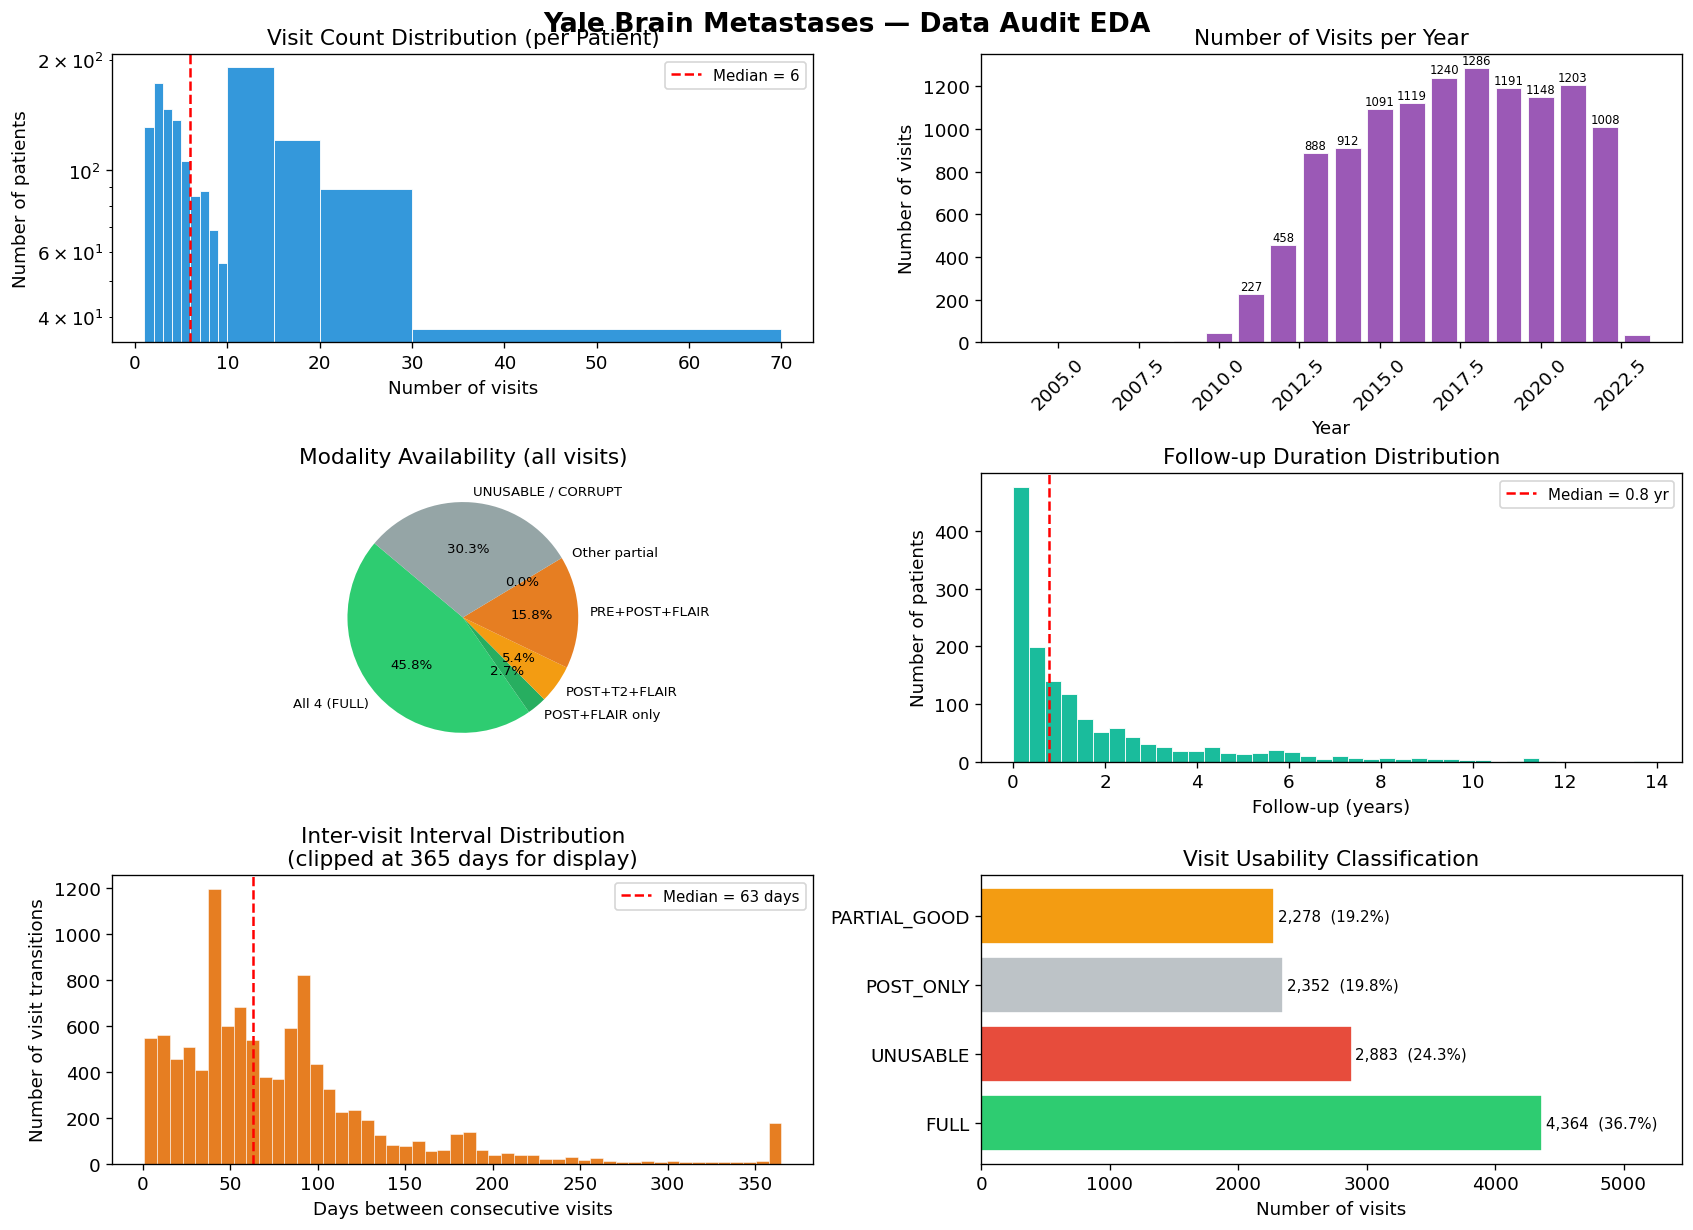


✅ Saved: /home/moamed/canada_me/explainable_diseas/implementation/outputs/eda/figures/01_full_eda_dashboard.png


In [16]:
PALETTE = {
    "FULL"         : "#2ecc71",
    "PARTIAL_GOOD" : "#f39c12",
    "UNUSABLE"     : "#e74c3c",
    "CORRUPT"      : "#95a5a6",
}
FIG_DPI   = 300
FIG_SIZE  = (14, 10)

fig = plt.figure(figsize=FIG_SIZE, constrained_layout=True)
fig.suptitle("Yale Brain Metastases — Data Audit EDA", fontsize=16, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(3, 2, figure=fig)

# ── Figure 1: Visit count distribution ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
vc_bins = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 70]
ax1.hist(patient_stats["n_visits"], bins=vc_bins, color="#3498db", edgecolor="white", linewidth=0.5)
ax1.set_title("Visit Count Distribution (per Patient)")
ax1.set_xlabel("Number of visits")
ax1.set_ylabel("Number of patients")
ax1.axvline(patient_stats["n_visits"].median(), color="red", linestyle="--", linewidth=1.5,
            label=f"Median = {patient_stats['n_visits'].median():.0f}")
ax1.legend(fontsize=9)
ax1.set_yscale("log")

# ── Figure 2: Visits per year ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
df["year"] = df["visit_date"].dt.year
year_counts = df.groupby("year").size()
ax2.bar(year_counts.index, year_counts.values, color="#9b59b6", edgecolor="white", linewidth=0.5)
ax2.set_title("Number of Visits per Year")
ax2.set_xlabel("Year")
ax2.set_ylabel("Number of visits")
ax2.tick_params(axis="x", rotation=45)
for bar, val in zip(ax2.patches, year_counts.values):
    if val > 100:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", va="bottom", fontsize=7)

# ── Figure 3: Modality availability (stacked bar) ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
mod_data = {
    "All 4 (FULL)"           : (df["usability"] == "FULL").sum(),
    "POST+FLAIR only"        : ((df["usability"] == "PARTIAL_GOOD") & ~df["has_PRE"] & ~df["has_T2"]).sum(),
    "POST+T2+FLAIR"          : ((df["usability"] == "PARTIAL_GOOD") & ~df["has_PRE"] & df["has_T2"]).sum(),
    "PRE+POST+FLAIR"         : ((df["usability"] == "PARTIAL_GOOD") & df["has_PRE"] & ~df["has_T2"]).sum(),
    "Other partial"          : ((df["usability"] == "PARTIAL_GOOD") &
                                ~((~df["has_PRE"] & ~df["has_T2"]) |
                                  (~df["has_PRE"] & df["has_T2"]) |
                                  (df["has_PRE"]  & ~df["has_T2"]))).sum(),
    "UNUSABLE / CORRUPT"     : df["usability"].isin(["UNUSABLE","CORRUPT"]).sum(),
}
colors = ["#2ecc71","#27ae60","#f39c12","#e67e22","#e74c3c","#95a5a6"]
wedges, texts, autotexts = ax3.pie(
    list(mod_data.values()), labels=list(mod_data.keys()),
    autopct="%1.1f%%", colors=colors, startangle=140,
    textprops={"fontsize": 8}
)
ax3.set_title("Modality Availability (all visits)")

# ── Figure 4: Follow-up duration histogram ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(patient_stats["followup_days"] / 365.25, bins=40, color="#1abc9c", edgecolor="white", linewidth=0.5)
ax4.set_title("Follow-up Duration Distribution")
ax4.set_xlabel("Follow-up (years)")
ax4.set_ylabel("Number of patients")
med_fu = patient_stats["followup_days"].median() / 365.25
ax4.axvline(med_fu, color="red", linestyle="--", linewidth=1.5, label=f"Median = {med_fu:.1f} yr")
ax4.legend(fontsize=9)

# ── Figure 5: Inter-visit interval histogram ─────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
intervals = df["interval_days"].dropna()
intervals_clipped = intervals.clip(upper=365)  # clip at 1 year for readability
ax5.hist(intervals_clipped, bins=50, color="#e67e22", edgecolor="white", linewidth=0.3)
ax5.set_title("Inter-visit Interval Distribution\n(clipped at 365 days for display)")
ax5.set_xlabel("Days between consecutive visits")
ax5.set_ylabel("Number of visit transitions")
med_int = intervals.median()
ax5.axvline(med_int, color="red", linestyle="--", linewidth=1.5, label=f"Median = {med_int:.0f} days")
ax5.legend(fontsize=9)

# ── Figure 6: Usability classification ───────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
usability_vc = df["usability"].value_counts()
bar_colors = [PALETTE.get(u, "#bdc3c7") for u in usability_vc.index]
bars = ax6.barh(usability_vc.index, usability_vc.values, color=bar_colors, edgecolor="white")
ax6.set_title("Visit Usability Classification")
ax6.set_xlabel("Number of visits")
for bar, val in zip(bars, usability_vc.values):
    ax6.text(val + 30, bar.get_y() + bar.get_height()/2,
             f"{val:,}  ({100*val/len(df):.1f}%)", va="center", fontsize=9)
ax6.set_xlim(0, usability_vc.max() * 1.25)

# ── Save ─────────────────────────────────────────────────────────────────────
FIG1_PATH = EDA_DIR / "01_full_eda_dashboard.png"
fig.savefig(FIG1_PATH, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"\n✅ Saved: {FIG1_PATH}")

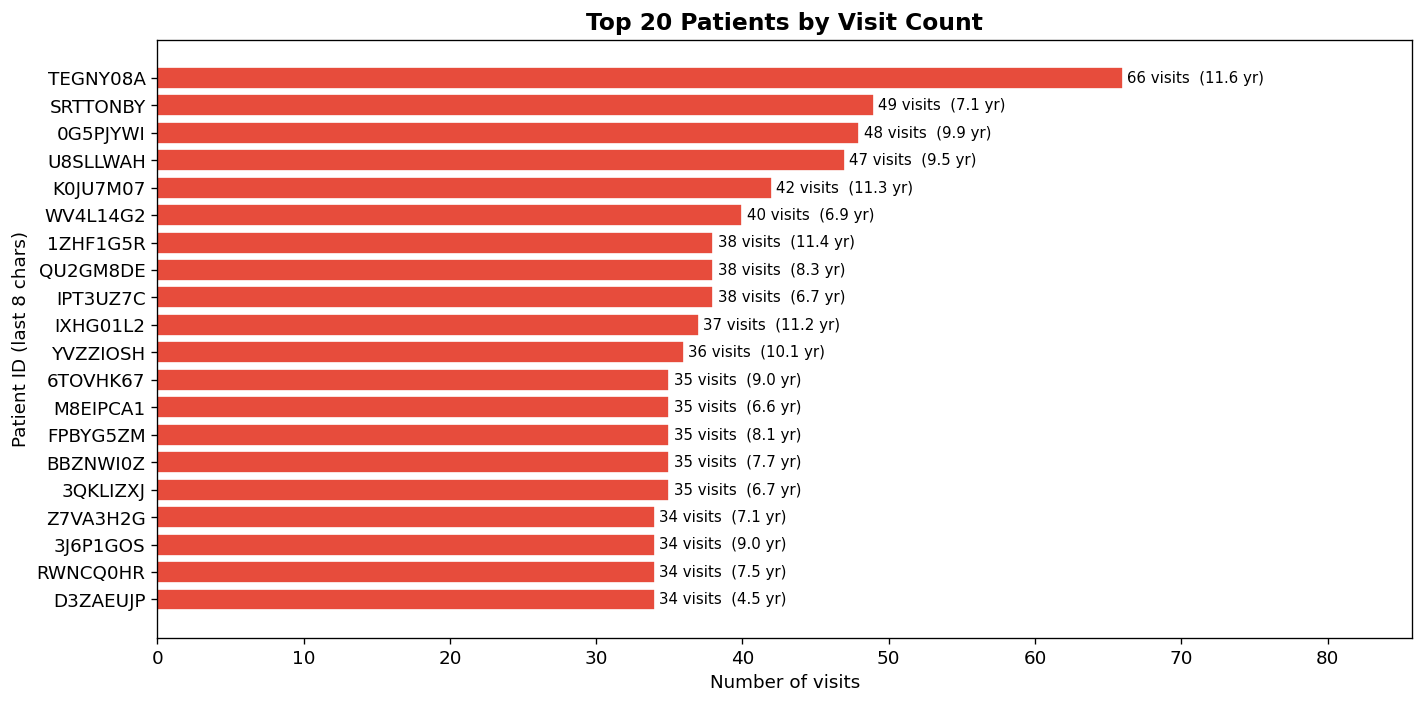

✅ Saved: /home/moamed/canada_me/explainable_diseas/implementation/outputs/eda/figures/02_top20_patients.png

   Top 5 patients:
     patient_id  n_visits  followup_years
YG_C9D2TEGNY08A        66           11.63
YG_NRSFSRTTONBY        49            7.12
YG_2LEC0G5PJYWI        48            9.91
YG_Y57DU8SLLWAH        47            9.52
YG_MTO9K0JU7M07        42           11.30


In [17]:
# ── Figure 7: Top 20 patients by visit count (bonus) ─────────────────────────
fig2, ax = plt.subplots(figsize=(12, 6))
top20 = patient_stats.nlargest(20, "n_visits")[["patient_id", "n_visits", "followup_years", "usability" if "usability" in patient_stats.columns else "n_full"]].copy()
top20["label"] = top20["patient_id"].str[-8:]  # shorten ID for display

colors_top = ["#e74c3c" if n > 20 else "#3498db" if n > 10 else "#2ecc71" for n in top20["n_visits"]]
bars = ax.barh(top20["label"], top20["n_visits"], color=colors_top, edgecolor="white")
ax.set_title("Top 20 Patients by Visit Count", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of visits")
ax.set_ylabel("Patient ID (last 8 chars)")
for bar, row in zip(bars, top20.itertuples()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row.n_visits} visits  ({row.followup_years:.1f} yr)", va="center", fontsize=9)
ax.set_xlim(0, top20["n_visits"].max() * 1.3)
ax.invert_yaxis()

FIG2_PATH = EDA_DIR / "02_top20_patients.png"
fig2.tight_layout()
fig2.savefig(FIG2_PATH, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {FIG2_PATH}")

# Print top 5 in text
print("\n   Top 5 patients:")
print(top20[["patient_id","n_visits","followup_years"]].head(5).to_string(index=False))

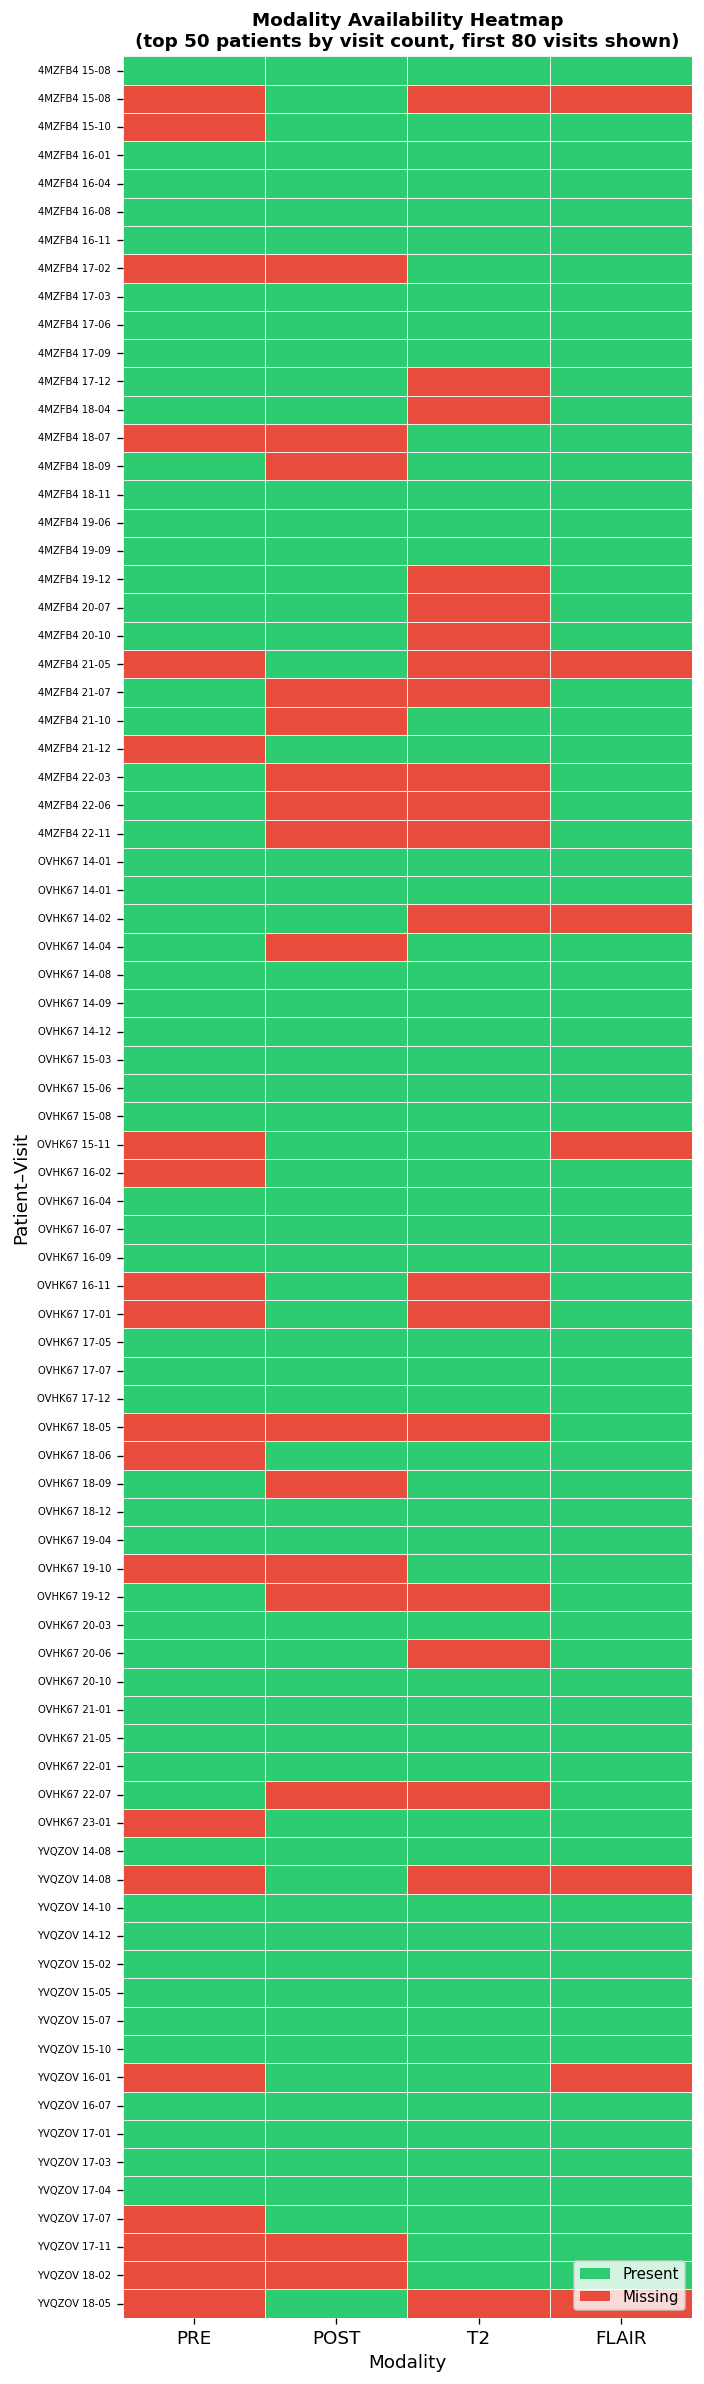

✅ Saved: /home/moamed/canada_me/explainable_diseas/implementation/outputs/eda/figures/03_modality_heatmap.png


In [18]:
# ── Figure 8: Missing modality heatmap ───────────────────────────────────────
# For a random sample of 100 patients: show which modalities are present per visit

sample_pids = patient_stats.nlargest(50, "n_visits")["patient_id"].tolist()
df_sample   = df[df["patient_id"].isin(sample_pids)].copy()

# Pivot: rows = visit (patient+date), columns = modality, value = 1/0
df_sample["visit_label"] = df_sample["patient_id"].str[-6:] + " " + df_sample["visit_date"].dt.strftime("%y-%m")
heatmap_data = df_sample[["visit_label", "has_PRE", "has_POST", "has_T2", "has_FLAIR"]].copy()
heatmap_data = heatmap_data.rename(columns={"has_PRE":"PRE","has_POST":"POST","has_T2":"T2","has_FLAIR":"FLAIR"})
heatmap_data = heatmap_data.set_index("visit_label")
heatmap_data = heatmap_data.astype(int)

# Limit to first 80 visits for display
heatmap_data = heatmap_data.head(80)

fig3, ax = plt.subplots(figsize=(6, min(20, len(heatmap_data) * 0.25 + 2)))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap=["#e74c3c", "#2ecc71"],
    linewidths=0.3,
    linecolor="#f0f0f0",
    cbar=False,
    yticklabels=True,
)
ax.set_title("Modality Availability Heatmap\n(top 50 patients by visit count, first 80 visits shown)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Modality")
ax.set_ylabel("Patient–Visit")
ax.tick_params(axis="y", labelsize=6)

# Legend patches
from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#2ecc71", label="Present"), Patch(facecolor="#e74c3c", label="Missing")]
ax.legend(handles=legend_els, loc="lower right", fontsize=9)

FIG3_PATH = EDA_DIR / "03_modality_heatmap.png"
fig3.tight_layout()
fig3.savefig(FIG3_PATH, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {FIG3_PATH}")

---
## Section 12 — GPU-Accelerated Statistics (Optional)

If a GPU is available, we use PyTorch tensors to compute population-level statistics on the inventory DataFrame much faster than pandas on large arrays.  
On CPU-only machines this falls back to NumPy — the results are identical.

This section demonstrates the GPU-accelerated stats pattern that will be reused in Phase 2 (CNN feature maps) and Phase 3 (Swin UNETR embeddings).

In [19]:
print(f"Running GPU-accelerated statistics on device: {DEVICE}")
print()

# Convert key numeric columns to tensors and send to device
numeric_cols = ["n_modalities", "days_since_baseline", "visit_idx"]
stats_df = df[numeric_cols].dropna()

for col in numeric_cols:
    t = torch.tensor(stats_df[col].values, dtype=torch.float32).to(DEVICE)
    print(f"  {col:<25}  mean={t.mean().item():>9.2f}  "
          f"std={t.std().item():>8.2f}  "
          f"min={t.min().item():>6.0f}  "
          f"max={t.max().item():>6.0f}")

print()
if GPU_MODE:
    mem_used = torch.cuda.memory_allocated(0) / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    print(f"  GPU memory used after stats: {mem_used:.1f} MB / {mem_total:.0f} MB")
    torch.cuda.empty_cache()
    print("  GPU cache cleared ✅")
else:
    print("  (CPU mode — no GPU memory to report)")
    print("  💡 On Kaggle T4, this will run on GPU automatically.")

Running GPU-accelerated statistics on device: cpu

  n_modalities               mean=     2.85  std=    1.11  min=     1  max=     4
  days_since_baseline        mean=   538.99  std=  672.64  min=     0  max=  5061
  visit_idx                  mean=     7.25  std=    7.62  min=     0  max=    65

  (CPU mode — no GPU memory to report)
  💡 On Kaggle T4, this will run on GPU automatically.


---
## Section 13 — Final Audit Report

We compile all findings into a single printed report and save `AUDIT_REPORT.md`.

In [20]:
n_patients     = df["patient_id"].nunique()
n_visits_total = len(df)
n_files_total  = df["n_nii_files"].sum()

n_full         = (df["training_usability"] == "FULL").sum()
n_partial      = (df["training_usability"] == "PARTIAL_GOOD").sum()
n_post_only    = (df["training_usability"] == "POST_ONLY").sum()
n_unusable     = (df["training_usability"] == "UNUSABLE").sum()
n_corrupt      = (df["training_usability"] == "CORRUPT").sum()

median_visits  = patient_stats["n_visits"].median()
median_fu_days = patient_stats["followup_days"].median()
max_fu_days    = patient_stats["followup_days"].max()
top_patient    = patient_stats.loc[patient_stats["n_visits"].idxmax(), "patient_id"]
top_patient_nv = patient_stats["n_visits"].max()

n_single_visit = (patient_stats["n_visits"] == 1).sum()
n_ge3_visits   = (patient_stats["n_visits"] >= 3).sum()
n_ge5_visits   = (patient_stats["n_visits"] >= 5).sum()

lines_corrupt  = df_integrity[df_integrity["error"].notna()][["patient_id","modality","error"]]

# ── Re-attach split column (may have been rebuilt by usability cell) ──────────
split_map_full = {pid: "train" for pid in train_pids}
split_map_full.update({pid: "val"   for pid in val_pids})
split_map_full.update({pid: "test"  for pid in test_pids})
df["split"] = df["patient_id"].map(split_map_full)

# ── Visit bucket table per split ──────────────────────────────────────────────
if "split" not in patient_stats.columns:
    patient_stats["split"] = patient_stats["patient_id"].map(split_map_full)

bucket_order = ["1", "2–3", "4–6", "7–10", ">10"]
bucket_table = (
    patient_stats
    .groupby(["visit_bucket", "split"])["patient_id"]
    .count()
    .unstack(fill_value=0)
    .reindex(bucket_order)
)
# reorder columns
for col in ["train", "val", "test"]:
    if col not in bucket_table.columns:
        bucket_table[col] = 0
bucket_table = bucket_table[["train", "val", "test"]]
bucket_table["TOTAL"] = bucket_table.sum(axis=1)
bucket_table_str = bucket_table.to_string()

report = f"""# Yale Brain Metastases — Data Audit Report
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Dataset Summary
| Metric | Value |
|--------|-------|
| Total patients | {n_patients:,} |
| Total visit folders | {n_visits_total:,} |
| Total NIfTI files | {n_files_total:,} |
| Median visits per patient | {median_visits:.1f} |
| Median follow-up | {median_fu_days:.0f} days |
| Max follow-up | {max_fu_days:,} days ({max_fu_days/365.25:.1f} years) |
| Top patient | {top_patient} ({top_patient_nv} visits) |

## Visit Training Usability Labels
> Note: All visits are real MRI data. This label describes HOW each visit
> can be used in the training pipeline — not whether the data is valid.

| Label | Count | % | Use |
|-------|-------|---|-----|
| FULL (all 4 modalities) | {n_full:,} | {100*n_full/n_visits_total:.1f}% | Full supervised training |
| PARTIAL_GOOD (POST+FLAIR ± others) | {n_partial:,} | {100*n_partial/n_visits_total:.1f}% | Supervised w/ modality dropout |
| POST_ONLY (POST present, no FLAIR) | {n_post_only:,} | {100*n_post_only/n_visits_total:.1f}% | Self-supervised pretraining only |
| UNUSABLE (no POST) | {n_unusable:,} | {100*n_unusable/n_visits_total:.1f}% | Temporal context only |
| CORRUPT (header errors) | {n_corrupt:,} | {100*n_corrupt/n_visits_total:.1f}% | Excluded entirely |

**Supervised training pool (FULL + PARTIAL_GOOD)**: {n_full + n_partial:,} visits ({100*(n_full+n_partial)/n_visits_total:.1f}%)
**Recoverable for pretraining (+ POST_ONLY)**: {n_full + n_partial + n_post_only:,} visits ({100*(n_full+n_partial+n_post_only)/n_visits_total:.1f}%)

## Longitudinal Eligibility
| Criterion | Patients |
|-----------|----------|
| Only 1 visit (not usable for longitudinal learning) | {n_single_visit:,} |
| ≥ 3 supervised visits | {n_ge3_visits:,} |
| ≥ 5 supervised visits (high priority) | {n_ge5_visits:,} |

## Visit Count Distribution by Split (Stratified)
```
{bucket_table_str}
```
> Rows = visit_bucket (number of visits per patient).
> Columns = patients in each split.
> Stratification ensures all temporal depths appear in train/val/test at the same ratio.

## Train/Val/Test Split
| Split | Patients | All Visits | Supervised Visits (FULL+PARTIAL) |
|-------|----------|------------|----------------------------------|
| Train | {len(train_pids):,} | {df[df['split']=='train'].shape[0]:,} | {df[(df['split']=='train') & df['training_usability'].isin(['FULL','PARTIAL_GOOD'])].shape[0]:,} |
| Val   | {len(val_pids):,} | {df[df['split']=='val'].shape[0]:,} | {df[(df['split']=='val') & df['training_usability'].isin(['FULL','PARTIAL_GOOD'])].shape[0]:,} |
| Test  | {len(test_pids):,} | {df[df['split']=='test'].shape[0]:,} | {df[(df['split']=='test') & df['training_usability'].isin(['FULL','PARTIAL_GOOD'])].shape[0]:,} |

Seed: {RANDOM_SEED} — **DO NOT REGENERATE**

## File Integrity
- Total files checked: {len(df_integrity):,}
- Files with header errors: {df_integrity['error'].notna().sum():,}
{"- " + chr(10) + "- ".join(lines_corrupt.to_string(index=False).split(chr(10))[:5]) if len(lines_corrupt) > 0 else "- No corrupt files found ✅"}

## Scanner Metadata Coverage
- Patients with clinical + scanner info: {len(metadata):,} / {n_patients:,} (100%)
- Fields available: age_at_imaging, sex, scanner vendor, model, field_strength (T), 2D/3D, scanner_site

## Output Files
| File | Location |
|------|----------|
| data_inventory.csv | `implementation/outputs/data_inventory.csv` |
| patient_timelines.json | `implementation/outputs/patient_timelines.json` |
| metadata.json | `implementation/outputs/metadata.json` |
| splits.json | `implementation/outputs/splits.json` |
| AUDIT_REPORT.md | `implementation/outputs/AUDIT_REPORT.md` |
| EDA figures (3 PNG) | `implementation/outputs/eda/figures/` |
"""

print(report)

REPORT_PATH = OUTPUTS_DIR / "AUDIT_REPORT.md"
with open(REPORT_PATH, "w") as f:
    f.write(report)

print(f"✅ Saved: {REPORT_PATH}")
print("\n" + "="*60)
print("  🎉  Phase 1 — Block 1: DATA AUDIT COMPLETE")
print("="*60)
print(f"\n  All outputs → {OUTPUTS_DIR}")
print(f"\n  ✅ Clinical Metadata Parsing — ALREADY DONE in this notebook!")
print(f"     metadata.json covers all {n_patients:,} patients")
print(f"     Fields: age, sex, vendor, model, field_strength, 2D/3D, site")
print(f"     Source: Clinical_data + Acquisition_data sheets from Excel")

# Yale Brain Metastases — Data Audit Report
Generated: 2026-03-10 15:50:41

## Dataset Summary
| Metric | Value |
|--------|-------|
| Total patients | 1,430 |
| Total visit folders | 11,877 |
| Total NIfTI files | 33,811 |
| Median visits per patient | 6.0 |
| Median follow-up | 288 days |
| Max follow-up | 5,061 days (13.9 years) |
| Top patient | YG_C9D2TEGNY08A (66 visits) |

## Visit Training Usability Labels
> Note: All visits are real MRI data. This label describes HOW each visit
> can be used in the training pipeline — not whether the data is valid.

| Label | Count | % | Use |
|-------|-------|---|-----|
| FULL (all 4 modalities) | 4,364 | 36.7% | Full supervised training |
| PARTIAL_GOOD (POST+FLAIR ± others) | 2,278 | 19.2% | Supervised w/ modality dropout |
| POST_ONLY (POST present, no FLAIR) | 2,352 | 19.8% | Self-supervised pretraining only |
| UNUSABLE (no POST) | 2,883 | 24.3% | Temporal context only |
| CORRUPT (header errors) | 0 | 0.0% | Excluded entirely |

**Super